In [6]:
from __future__ import annotations

import csv
import sys
from pathlib import Path
from typing import List, Tuple

import matplotlib.pyplot as plt

MOVING_WINDOW = 20


def _moving_window_mean(values: List[float], window: int = MOVING_WINDOW) -> List[float]:
    """Centered moving average with the given window size.

    Uses smaller windows at the boundaries to keep output length unchanged.
    """

    if window <= 1:
        return list(values)

    n = len(values)
    if n == 0:
        return []

    left = window // 2
    right = window - left

    out: List[float] = []
    for i in range(n):
        start = max(0, i - left)
        end = min(n, i + right)  # exclusive
        segment = values[start:end]
        out.append(sum(segment) / len(segment))

    return out


def _find_repo_root(start: Path | None = None) -> Path:
    """Walk upward until we find the project root (contains 'voltammetry-files')."""
    here = (start or Path.cwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "voltammetry-files").exists():
            return candidate
    raise FileNotFoundError("Could not find 'voltammetry-files' by walking upward from CWD")


def _load_voltammetry_txt(path: Path) -> Tuple[List[float], List[float], List[float]]:
    """Load a 3-column voltammetry text file: time, potential (V), current."""

    times: List[float] = []
    potentials: List[float] = []
    currents: List[float] = []

    with path.open("r", newline="") as f:
        reader = csv.reader(f)
        for row in reader:
            if not row:
                continue
            t_str, e_str, i_str = (cell.strip() for cell in row[:3])
            times.append(float(t_str))
            potentials.append(float(e_str))
            currents.append(float(i_str))

    return times, potentials, currents


# Optional: use the shared publication style module if it's importable.
_repo_root = _find_repo_root()
_thesis_dir = _repo_root / "ThesisPlotGeneration"
if _thesis_dir.exists():
    sys.path.insert(0, str(_thesis_dir))

# Where PDFs will be saved
PLOTS_DIR = _repo_root / "Plots"
PLOTS_DIR.mkdir(exist_ok=True)

try:
    from plot_generator import FIGSIZE_SINGLE_COLUMN, apply_publication_style

    apply_publication_style(figsize=FIGSIZE_SINGLE_COLUMN)
except Exception:
    # If the style module isn't available, plotting still works.
    pass


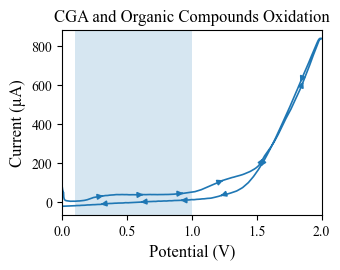

Saved: /Users/ryankoes/PycharmProjects/CoffeeAnalysis/Plots/CGARange.pdf


In [7]:
data_path = _repo_root / "voltammetry-files" / "AlabasterColumbiaReg1.txt"

_, potential_v, current = _load_voltammetry_txt(data_path)

# Ignore any data in negative voltage (keep potential/current aligned)
nonneg_pairs = [(v, i) for v, i in zip(potential_v, current) if v >= 0.0]
potential_v, current = (list(t) for t in zip(*nonneg_pairs))


def _add_direction_arrows(
    ax,
    x,
    y,
    *,
    n_arrows: int = 12,
    line=None,
    mutation_scale: float = 9,
):
    """Add small arrows along a polyline to indicate point order (sweep direction).

    Arrows are spaced by cumulative |Δx| (potential progress), which tends to
    distribute them more evenly across the x-axis than arc-length spacing.
    """

    n = min(len(x), len(y))
    if n < 2:
        return

    color = line.get_color() if line is not None else None
    lw = line.get_linewidth() if line is not None else 1.0

    # Cumulative potential progress along the trace (in data order)
    cumprog = [0.0]
    for i in range(1, n):
        dx = x[i] - x[i - 1]
        cumprog.append(cumprog[-1] + abs(dx))

    total = cumprog[-1]
    if total <= 0:
        return

    # Keep arrows short and subtle; scale arrow length down as arrow count increases.
    arrow_step = max(2, n // (n_arrows * 30))
    fracs = [(k + 1) / (n_arrows + 1) for k in range(n_arrows)]

    for frac in fracs:
        target = frac * total
        i = 0
        while i < n and cumprog[i] < target:
            i += 1
        if i >= n - 1:
            continue

        j = min(i + arrow_step, n - 1)
        if j == i:
            continue

        ax.annotate(
            "",
            xy=(x[j], y[j]),
            xytext=(x[i], y[i]),
            arrowprops=dict(
                arrowstyle="-|>",
                color=color,
                lw=lw,
                shrinkA=0,
                shrinkB=0,
                mutation_scale=mutation_scale,
            ),
            zorder=3,
        )


fig, ax = plt.subplots()

# Highlight region: 0.1 to 1.0 V
ax.axvspan(0.1, 1.0, alpha=0.18, zorder=0)

smoothed_current = _moving_window_mean(current)
(line,) = ax.plot(potential_v, smoothed_current, linewidth=1.2, zorder=2)

# Add small arrows to show sweep direction (voltage progression)
_add_direction_arrows(ax, potential_v, smoothed_current, n_arrows=12, line=line, mutation_scale=8)

ax.set_xlabel("Potential (V)")
ax.set_ylabel("Current (µA)")
ax.set_title("CGA and Organic Compounds Oxidation")

x_min = 0.0
x_max = max(max(potential_v), 1.0)
ax.set_xlim(x_min, x_max)

out_path = PLOTS_DIR / "CGARange.pdf"
fig.savefig(out_path, format="pdf", bbox_inches="tight")

plt.show()
print(f"Saved: {out_path}")


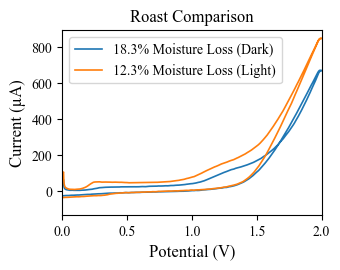

Saved: /Users/ryankoes/PycharmProjects/CoffeeAnalysis/Plots/Roast_Comparison.pdf


In [ ]:
# Plot SM15-1.txt and SM5-1.txt in the same plot

sm15_path = _repo_root / "voltammetry-files" / "L1.txt"
sm5_path = _repo_root / "voltammetry-files" / "H1.txt"

sm15_times, sm15_potential_v, sm15_current = _load_voltammetry_txt(sm15_path)
sm5_times, sm5_potential_v, sm5_current = _load_voltammetry_txt(sm5_path)

fig, ax = plt.subplots()

ax.plot(
    sm15_potential_v,
    _moving_window_mean(sm15_current),
    label="18.3% Mass Loss (Dark)",
    linewidth=1.2,
    zorder=2,
)
ax.plot(
    sm5_potential_v,
    _moving_window_mean(sm5_current),
    label="12.3% Mass Loss (Light)",
    linewidth=1.2,
    zorder=2,
)
ax.set_xlabel("Potential (V)")
ax.set_ylabel("Current (µA)")
ax.set_title("Roast Comparison")
ax.legend()
x_min = 0.0
x_max = max(max(sm15_potential_v), max(sm5_potential_v), 1.0)
ax.set_xlim(x_min, x_max)
out_path = PLOTS_DIR / "Roast_Comparison.pdf"
fig.savefig(out_path, format="pdf", bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

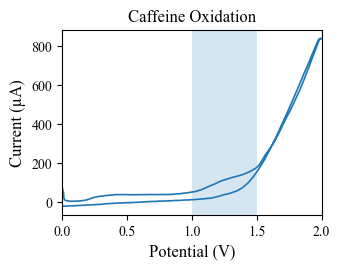

Saved: /Users/ryankoes/PycharmProjects/CoffeeAnalysis/Plots/CaffeineOxidation.pdf


In [4]:
data_path = _repo_root / "voltammetry-files" / "AlabasterColumbiaReg1.txt"

_, potential_v, current = _load_voltammetry_txt(data_path)

# Ignore any data in negative voltage (keep potential/current aligned)
nonneg_pairs = [(v, i) for v, i in zip(potential_v, current) if v >= 0.0]
potential_v, current = (list(t) for t in zip(*nonneg_pairs))

fig, ax = plt.subplots()

ax.axvspan(1.0, 1.5, alpha=0.18, zorder=0)

ax.plot(potential_v, _moving_window_mean(current), linewidth=1.2, zorder=2)

ax.set_xlabel("Potential (V)")
ax.set_ylabel("Current (µA)")
ax.set_title("Caffeine Oxidation")

x_min = 0.0
x_max = max(max(potential_v), 1.0)
ax.set_xlim(x_min, x_max)

out_path = PLOTS_DIR / "CaffeineOxidation.pdf"
fig.savefig(out_path, format="pdf", bbox_inches="tight")

plt.show()
print(f"Saved: {out_path}")


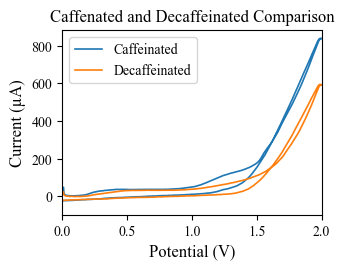

Saved: /Users/ryankoes/PycharmProjects/CoffeeAnalysis/Plots/CaffenatedDecaffeinatedComparison.pdf


In [5]:
# Plot SM15-1.txt and SM5-1.txt in the same plot

sm15_path = _repo_root / "voltammetry-files" / "AlabasterColumbiaReg1.txt"
sm5_path = _repo_root / "voltammetry-files" / "AlabasterColumbiaDecaf1.txt"

sm15_times, sm15_potential_v, sm15_current = _load_voltammetry_txt(sm15_path)
sm5_times, sm5_potential_v, sm5_current = _load_voltammetry_txt(sm5_path)

fig, ax = plt.subplots()

ax.plot(
    sm15_potential_v,
    _moving_window_mean(sm15_current),
    label="Caffeinated",
    linewidth=1.2,
    zorder=2,
)
ax.plot(
    sm5_potential_v,
    _moving_window_mean(sm5_current),
    label="Decaffeinated",
    linewidth=1.2,
    zorder=2,
)
ax.set_xlabel("Potential (V)")
ax.set_ylabel("Current (µA)")
ax.set_title("Caffenated and Decaffeinated Comparison")
ax.legend()
x_min = 0.0
x_max = max(max(sm15_potential_v), max(sm5_potential_v), 1.0)
ax.set_xlim(x_min, x_max)
out_path = PLOTS_DIR / "CaffenatedDecaffeinatedComparison.pdf"
fig.savefig(out_path, format="pdf", bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

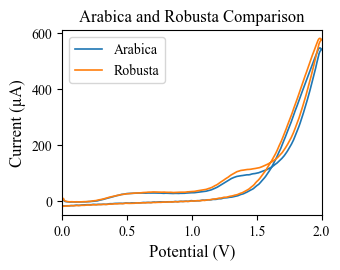

Saved: /Users/ryankoes/PycharmProjects/CoffeeAnalysis/Plots/Arabica_Robusta_Comparison.pdf


In [6]:
sm15_path = _repo_root / "extra-voltammetry-files" / "BrazilRegular.txt"
sm5_path = _repo_root / "extra-voltammetry-files" / "UgandanRobusta.txt"

sm15_times, sm15_potential_v, sm15_current = _load_voltammetry_txt(sm15_path)
sm5_times, sm5_potential_v, sm5_current = _load_voltammetry_txt(sm5_path)

fig, ax = plt.subplots()

ax.plot(
    sm15_potential_v,
    _moving_window_mean(sm15_current),
    label="Arabica",
    linewidth=1.2,
    zorder=2,
)
ax.plot(
    sm5_potential_v,
    _moving_window_mean(sm5_current),
    label="Robusta",
    linewidth=1.2,
    zorder=2,
)
ax.set_xlabel("Potential (V)")
ax.set_ylabel("Current (µA)")
ax.set_title("Arabica and Robusta Comparison")
ax.legend()
x_min = 0.0
x_max = max(max(sm15_potential_v), max(sm5_potential_v), 1.0)
ax.set_xlim(x_min, x_max)
out_path = PLOTS_DIR / "Arabica_Robusta_Comparison.pdf"
fig.savefig(out_path, format="pdf", bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

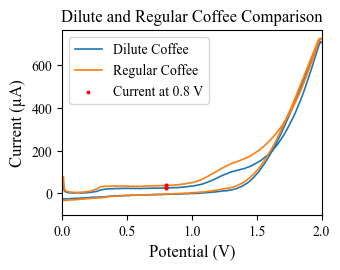

Saved: /Users/ryankoes/PycharmProjects/CoffeeAnalysis/Plots/Dilute_Regular_Coffee_Comparison.pdf


In [7]:
sm15_path = _repo_root / "voltammetry-files" / "O2.txt"
sm5_path = _repo_root / "voltammetry-files" / "K1.txt"

sm15_times, sm15_potential_v, sm15_current = _load_voltammetry_txt(sm15_path)
sm5_times, sm5_potential_v, sm5_current = _load_voltammetry_txt(sm5_path)

fig, ax = plt.subplots()

ax.plot(
    sm15_potential_v,
    _moving_window_mean(sm15_current),
    label="Dilute Coffee",
    linewidth=1.2,
    zorder=2,
)
ax.plot(
    sm5_potential_v,
    _moving_window_mean(sm5_current),
    label="Regular Coffee",
    linewidth=1.2,
    zorder=2,
)
ax.set_xlabel("Potential (V)")
ax.set_ylabel("Current (µA)")
ax.set_title("Dilute and Regular Coffee Comparison")

# Put a dot on highest point of dilute coffee (0.8 V) for each coffee type
# make the dot smaller and black so it stands out but doesn't distract from the main plot
max_idx_15 = sm15_potential_v.index(0.8)
ax.scatter(sm15_potential_v[max_idx_15], _moving_window_mean(sm15_current)[max_idx_15], color="red", zorder=3, s=3)
max_idx_5 = sm5_potential_v.index(0.8)
ax.scatter(sm5_potential_v[max_idx_5], _moving_window_mean(sm5_current)[max_idx_5], color="red", zorder=3, s=3)

# Put the red dot and description in the legend
ax.scatter(sm15_potential_v[max_idx_15], _moving_window_mean(sm15_current)[max_idx_15], color="red", zorder=3, s=3, label="Current at 0.8 V")
ax.scatter(sm5_potential_v[max_idx_5], _moving_window_mean(sm5_current)[max_idx_5], color="red", zorder=3, s=3)

ax.legend()

x_min = 0.0
x_max = max(max(sm15_potential_v), max(sm5_potential_v), 1.0)
ax.set_xlim(x_min, x_max)
out_path = PLOTS_DIR / "Dilute_Regular_Coffee_Comparison.pdf"
fig.savefig(out_path, format="pdf", bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

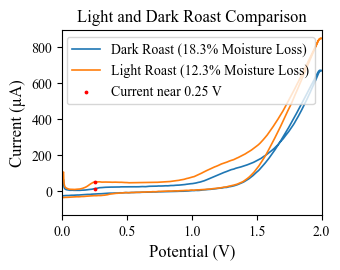

Saved: /Users/ryankoes/PycharmProjects/CoffeeAnalysis/Plots/Light_Dark_point.pdf


In [8]:
sm15_path = _repo_root / "voltammetry-files" / "L1.txt"
sm5_path = _repo_root / "voltammetry-files" / "H1.txt"

sm15_times, sm15_potential_v, sm15_current = _load_voltammetry_txt(sm15_path)
sm5_times, sm5_potential_v, sm5_current = _load_voltammetry_txt(sm5_path)

fig, ax = plt.subplots()

ax.plot(
    sm15_potential_v,
    _moving_window_mean(sm15_current),
    label="Dark Roast (18.3% Moisture Loss)",
    linewidth=1.2,
    zorder=2,
)
ax.plot(
    sm5_potential_v,
    _moving_window_mean(sm5_current),
    label="Light Roast (12.3% Moisture Loss)",
    linewidth=1.2,
    zorder=2,
)
ax.set_xlabel("Potential (V)")
ax.set_ylabel("Current (µA)")
ax.set_title("Light and Dark Roast Comparison")

# Put a dot near 0.8 V for each curve (use nearest point to avoid float exact-match issues)
target_v = 0.25

max_idx_15 = min(range(len(sm15_potential_v)), key=lambda i: abs(sm15_potential_v[i] - target_v))
ax.scatter(
    sm15_potential_v[max_idx_15],
    _moving_window_mean(sm15_current)[max_idx_15],
    color="red",
    zorder=2,
    s=3,
    label="Current near 0.25 V",
)

max_idx_5 = min(range(len(sm5_potential_v)), key=lambda i: abs(sm5_potential_v[i] - target_v))
ax.scatter(
    sm5_potential_v[max_idx_5],
    _moving_window_mean(sm5_current)[max_idx_5],
    color="red",
    zorder=2,
    s=3,
)

ax.legend()

x_min = 0.0
x_max = max(max(sm15_potential_v), max(sm5_potential_v), 1.0)
ax.set_xlim(x_min, x_max)
out_path = PLOTS_DIR / "Light_Dark_point.pdf"
fig.savefig(out_path, format="pdf", bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

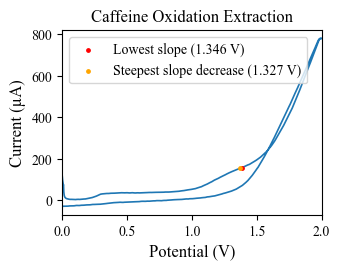

Saved: /Users/ryankoes/PycharmProjects/CoffeeAnalysis/Plots/CaffeineOxidation_lowest_slope.pdf
Lowest |dI/dV| point in [1.28, 1.6] V (oxidation): V=1.384 V, I=157.16 µA
Steepest slope decrease point in [1.1, 1.5] V (oxidation): V=1.374 V, I=155.03 µA


In [33]:
import numpy as np

data_path = _repo_root / "voltammetry-files" / "D1.txt"
_, potential_v, current = _load_voltammetry_txt(data_path)

# Ignore any data in negative voltage (keep potential/current aligned)
nonneg_pairs = [(v, i) for v, i in zip(potential_v, current) if v >= 0.0]
potential_v, current = (list(t) for t in zip(*nonneg_pairs))

# Compute on oxidation sweep only (first up-scan)
potential_arr = np.asarray(potential_v, dtype=float)
current_sm = np.asarray(_moving_window_mean(current), dtype=float)

i_max = int(np.argmax(potential_arr))
potential_ox = potential_arr[: i_max + 1]
current_ox = current_sm[: i_max + 1]

# 1) Red dot: lowest |dI/dV| between 1.2–1.6 V (flattest point)
vmin_flat, vmax_flat = 1.28, 1.6
mask_flat = (potential_ox >= vmin_flat) & (potential_ox <= vmax_flat)
if int(np.sum(mask_flat)) < 3:
    raise ValueError(f"Need at least 3 oxidation points within [{vmin_flat}, {vmax_flat}] V")

v_win_flat = potential_ox[mask_flat]
i_win_flat = current_ox[mask_flat]
slope_flat = np.gradient(i_win_flat, v_win_flat)
pick_flat = int(np.argmin(np.abs(slope_flat)))

v_pick_flat = float(v_win_flat[pick_flat])
i_pick_flat = float(i_win_flat[pick_flat])

# 2) Orange dot: steepest slope decrease between 1.1–1.5 V (min d²I/dV²)
vmin_curv, vmax_curv = 1.10, 1.5
mask_curv = (potential_ox >= vmin_curv) & (potential_ox <= vmax_curv)
if int(np.sum(mask_curv)) < 5:
    raise ValueError(f"Need at least 5 oxidation points within [{vmin_curv}, {vmax_curv}] V")

v_win_curv = potential_ox[mask_curv]
i_win_curv = current_ox[mask_curv]
di_dv = np.gradient(i_win_curv, v_win_curv)
d2i_dv2 = np.gradient(di_dv, v_win_curv)
pick_curv = int(np.argmin(d2i_dv2))

v_pick_curv = float(v_win_curv[pick_curv])
i_pick_curv = float(i_win_curv[pick_curv])

fig, ax = plt.subplots()
ax.plot(potential_arr, current_sm, linewidth=1.2, zorder=2)
ax.scatter(v_pick_flat, i_pick_flat, color="red", zorder=3, s=6, label="Lowest slope (1.346 V)")
ax.scatter(v_pick_curv, i_pick_curv, color="orange", zorder=3, s=6, label="Steepest slope decrease (1.327 V)")

ax.set_xlabel("Potential (V)")
ax.set_ylabel("Current (µA)")
ax.set_title("Caffeine Oxidation Extraction")
ax.legend()

x_min = 0.0
x_max = max(float(np.max(potential_arr)), 1.0)
ax.set_xlim(x_min, x_max)

out_path = PLOTS_DIR / "CaffeineOxidation_lowest_slope.pdf"
fig.savefig(out_path, format="pdf", bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")
print(f"Lowest |dI/dV| point in [{vmin_flat}, {vmax_flat}] V (oxidation): V={v_pick_flat:.6g} V, I={i_pick_flat:.6g} µA")
print(f"Steepest slope decrease point in [{vmin_curv}, {vmax_curv}] V (oxidation): V={v_pick_curv:.6g} V, I={i_pick_curv:.6g} µA")

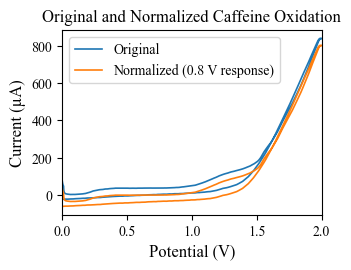

Saved: /Users/ryankoes/PycharmProjects/CoffeeAnalysis/Plots/AlabasterColumbia_original_subtracted.pdf


In [36]:
# Graph the AlabasterCombian1 file on a plot and the same file with every point subtracted by the response at 0.8 V

data_path = _repo_root / "voltammetry-files" / "AlabasterColumbiaReg1.txt"
_, potential_v, current = _load_voltammetry_txt(data_path)

# Ignore any data in negative voltage (keep potential/current aligned)
nonneg_pairs = [(v, i) for v, i in zip(potential_v, current) if v >= 0.0]
potential_v, current = (list(t) for t in zip(*nonneg_pairs))
current_arr = np.asarray(_moving_window_mean(current), dtype=float)
potential_arr = np.asarray(potential_v, dtype=float)
# Find current at 0.8 V (use nearest point to avoid float exact-match issues)
target_v = 0.8
idx_target = int(np.argmin(np.abs(potential_arr - target_v)))
i_target = float(current_arr[idx_target])
current_subtracted = current_arr - i_target
fig, ax = plt.subplots()
ax.plot(potential_arr, current_arr, label="Original", linewidth=1.2, zorder=2)
ax.plot(potential_arr, current_subtracted, label="Normalized (0.8 V response)", linewidth=1.2, zorder=2)
ax.set_xlabel("Potential (V)")
ax.set_ylabel("Current (µA)")
ax.set_title("Original and Normalized Caffeine Oxidation")
ax.legend()
x_min = 0.0
x_max = max(float(np.max(potential_arr)), 1.0)
ax.set_xlim(x_min, x_max)
out_path = PLOTS_DIR / "AlabasterColumbia_original_subtracted.pdf"
fig.savefig(out_path, format="pdf", bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

Saved: /Users/ryankoes/PycharmProjects/CoffeeAnalysis/Plots/CGA_regression_I0p8V.pdf
N=132 curves
Fit: HPLC_CGA = 19.0947 * I0.8 + -55.9781
R²=0.343252, MAE=186.441 ppm


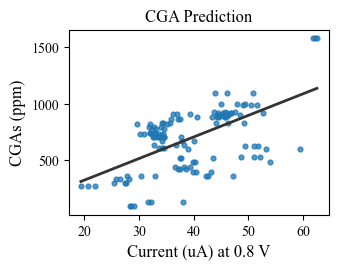

In [37]:
# Comment: CGA regression using current at 0.8 V

import sys
from pathlib import Path

# Ensure repo root (where regression_cga_at_0p8V.py lives) is importable
sys.path.insert(0, str(_repo_root))

from regression_cga_at_0p8V import build_dataset, fit_and_plot

# Build dataset: (I at ~0.8 V on oxidation sweep) -> HPLC_CGA truth
points = build_dataset(_repo_root, v_target=0.8, smooth_window=20)

out_path = _repo_root / "Plots" / "CGA_regression_I0p8V.pdf"
fit_and_plot(points, out_path, show=True)

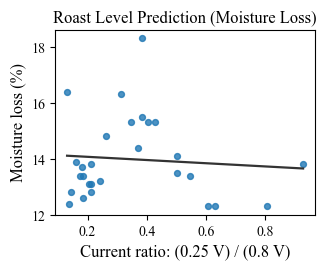

Saved: /Users/ryankoes/PycharmProjects/CoffeeAnalysis/Plots/Roast_regression_I0p25_over_I0p8.pdf
N=28 coffees (1 sample per CoffeeHub row)
Skipped: 27 rows (non-numeric `Roast`), 0 rows (no usable volt curves)
Fit: moisture_loss = -0.572415 * ratio + 14.1823
R²=0.00662869, MAE=1.14597 %


In [46]:
# Roast regression using ratio: I(0.25 V) / I(0.8 V) -> % moisture loss (from CoffeeHub `Roast` column)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

import sys
import numpy as np

# Ensure repo root is importable (for util.read_coffehub)
sys.path.insert(0, str(_repo_root))
from util import read_coffehub

def _parse_moisture_loss(roast_value) -> float | None:
    """Parse CoffeeHub `Roast` field as moisture-loss percent (float).

    Accepts numbers, "12.3", "12.3%", and ignores non-numeric roast labels.
    """
    if roast_value is None:
        return None
    try:
        # pandas NaN check
        import pandas as pd
        if pd.isna(roast_value):
            return None
    except Exception:
        pass

    if isinstance(roast_value, (int, float, np.integer, np.floating)):
        val = float(roast_value)
        return val if np.isfinite(val) else None

    s = str(roast_value).strip()
    if not s:
        return None
    if s.endswith("%"):
        s = s[:-1].strip()
    try:
        val = float(s)
    except ValueError:
        return None
    return val if np.isfinite(val) else None


def _oxidation_segment(potential_v: np.ndarray, current_ua: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Return oxidation sweep (initial up-scan): start -> first max potential."""
    if potential_v.size == 0:
        return potential_v, current_ua
    i_max = int(np.argmax(potential_v))
    if i_max == 0 and potential_v.size > 1:
        # likely reversed ordering
        potential_v = potential_v[::-1]
        current_ua = current_ua[::-1]
        i_max = int(np.argmax(potential_v))
    return potential_v[: i_max + 1], current_ua[: i_max + 1]


def _nearest_index(values: np.ndarray, target: float) -> int:
    return int(np.argmin(np.abs(values - target)))


volt_dirs = [
    _repo_root / "voltammetry-files",
    _repo_root / "extra-voltammetry-files",
]


def _extract_ratio(volt_file: str, *, v_num: float = 0.25, v_den: float = 0.8, eps: float = 1e-9) -> float | None:
    volt_file = str(volt_file).strip()
    if not volt_file:
        return None

    path = None
    for d in volt_dirs:
        candidate = d / volt_file
        if candidate.exists():
            path = candidate
            break
    if path is None:
        print(f"Missing voltammetry file: {volt_file}")
        return None

    _, potential_v, current = _load_voltammetry_txt(path)
    potential_arr = np.asarray(potential_v, dtype=float)
    current_arr = np.asarray(_moving_window_mean(current), dtype=float)

    # keep non-negative potentials
    mask_nonneg = potential_arr >= 0.0
    potential_arr = potential_arr[mask_nonneg]
    current_arr = current_arr[mask_nonneg]

    # oxidation only
    potential_ox, current_ox = _oxidation_segment(potential_arr, current_arr)

    idx_num = _nearest_index(potential_ox, v_num)
    idx_den = _nearest_index(potential_ox, v_den)
    i_num = float(current_ox[idx_num])
    i_den = float(current_ox[idx_den])

    if abs(i_den) < eps:
        print(f"Skipping {volt_file}: I({v_den} V) too close to 0 (I={i_den:.6g} µA)")
        return None
    return i_num / i_den


# Load CoffeeHub truth (from cache when available) and build dataset
df = read_coffehub(use_cache=True)
required_cols = {"Name", "Roast", "cv_data1", "cv_data2", "cv_data3"}
missing = sorted(c for c in required_cols if c not in df.columns)
if missing:
    raise KeyError(f"CoffeeHub data missing required columns: {missing}")

ratio_samples: list[float] = []
moisture_samples: list[float] = []

skipped_roast = 0
skipped_no_curves = 0

for _, row in df.iterrows():
    moisture_loss = _parse_moisture_loss(row.get("Roast"))
    if moisture_loss is None:
        skipped_roast += 1
        continue

    ratios_row: list[float] = []
    for col in ("cv_data1", "cv_data2", "cv_data3"):
        vf = row.get(col)
        r = _extract_ratio(vf, v_num=0.25, v_den=0.8)
        if r is None:
            continue
        ratios_row.append(float(r))

    if not ratios_row:
        skipped_no_curves += 1
        continue

    # One sample per coffee: average available replicate curves
    ratio_samples.append(float(np.mean(ratios_row)))
    moisture_samples.append(float(moisture_loss))

x = np.asarray(ratio_samples, dtype=float).reshape(-1, 1)
y = np.asarray(moisture_samples, dtype=float)

if x.size == 0:
    raise ValueError("No usable roast samples found: check that `Roast` is numeric moisture-loss % and cv_data files exist")

model = LinearRegression()
model.fit(x, y)
y_pred = model.predict(x)
r2 = float(r2_score(y, y_pred))
mae = float(mean_absolute_error(y, y_pred))

fig, ax = plt.subplots()
ax.scatter(x[:, 0], y, s=18, alpha=0.8, zorder=2)

x_min, x_max = float(np.min(x)), float(np.max(x))
x_line = np.linspace(x_min, x_max, 200).reshape(-1, 1)
y_line = model.predict(x_line)
ax.plot(x_line[:, 0], y_line, color="0.2", linewidth=1.6, zorder=3)

ax.set_xlabel("Current ratio: (0.25 V) / (0.8 V)")
ax.set_ylabel("Moisture loss (%)")
ax.set_title("Roast Level Prediction (Moisture Loss)")

out_path = PLOTS_DIR / "Roast_regression_I0p25_over_I0p8.pdf"
fig.savefig(out_path, format="pdf", bbox_inches="tight")
plt.show()

print(f"Saved: {out_path}")
print(f"N={len(y)} coffees (1 sample per CoffeeHub row)")
print(f"Skipped: {skipped_roast} rows (non-numeric `Roast`), {skipped_no_curves} rows (no usable volt curves)")
print(f"Fit: moisture_loss = {model.coef_[0]:.6g} * ratio + {model.intercept_:.6g}")
print(f"R²={r2:.6g}, MAE={mae:.6g} %")


In [34]:
# Generate a single PDF with three caffeine regression plots (3 pages):
# 1) Best-voltage regression (voltage chosen by scanning for max R²)
# 2) Plateau-point regression (lowest |dI/dV| in caffeine oxidation range)
# 3) Bump-point regression (steepest descent in slope via min d²I/dV²)
#
# This cell ONLY computes the regression inputs + fits and stores them in `caff_raw_results`.
# Plotting/saving is in the next cell so you can tweak aesthetics without rerunning regression.

import sys
from pathlib import Path

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Ensure repo root is importable (for util.read_coffehub)
sys.path.insert(0, str(_repo_root))
from util import read_coffehub


def _oxidation_segment(potential_v: np.ndarray, current_ua: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Return oxidation sweep (initial up-scan): start -> first max potential."""
    if potential_v.size == 0:
        return potential_v, current_ua
    i_max = int(np.argmax(potential_v))
    if i_max == 0 and potential_v.size > 1:
        # likely reversed ordering
        potential_v = potential_v[::-1]
        current_ua = current_ua[::-1]
        i_max = int(np.argmax(potential_v))
    return potential_v[: i_max + 1], current_ua[: i_max + 1]


def _nearest_index(values: np.ndarray, target: float) -> int:
    return int(np.argmin(np.abs(values - target)))


# Search order for voltammetry files
volt_dirs = [
    _repo_root / "voltammetry-files",
    _repo_root / "extra-voltammetry-files",
]


def _resolve_volt_path(volt_file: str) -> "Path | None":
    if volt_file is None:
        return None
    vf = str(volt_file).strip()
    if not vf:
        return None
    for d in volt_dirs:
        candidate = d / vf
        if candidate.exists():
            return candidate
    return None


def _load_curve_oxidation_smoothed(path: Path) -> tuple[np.ndarray, np.ndarray] | None:
    _, potential_v, current = _load_voltammetry_txt(path)
    potential_arr = np.asarray(potential_v, dtype=float)
    current_arr = np.asarray(_moving_window_mean(current), dtype=float)
    mask_nonneg = potential_arr >= 0.0
    potential_arr = potential_arr[mask_nonneg]
    current_arr = current_arr[mask_nonneg]
    potential_ox, current_ox = _oxidation_segment(potential_arr, current_arr)
    if potential_ox.size < 3:
        return None
    return potential_ox, current_ox


def _feature_at_voltage(potential_ox: np.ndarray, current_ox: np.ndarray, v: float) -> float:
    idx = _nearest_index(potential_ox, v)
    return float(current_ox[idx])


def _feature_plateau_lowest_slope(
    potential_ox: np.ndarray,
    current_ox: np.ndarray,
    *,
    vmin: float = 1.2,
    vmax: float = 1.6,
) -> float | None:
    mask = (potential_ox >= vmin) & (potential_ox <= vmax)
    if int(np.sum(mask)) < 3:
        return None
    v_win = potential_ox[mask]
    i_win = current_ox[mask]
    slope = np.gradient(i_win, v_win)
    pick = int(np.argmin(np.abs(slope)))
    return float(i_win[pick])


def _feature_bump_steepest_slope_descent(
    potential_ox: np.ndarray,
    current_ox: np.ndarray,
    *,
    vmin: float = 1.25,
    vmax: float = 1.5,
) -> float | None:
    mask = (potential_ox >= vmin) & (potential_ox <= vmax)
    if int(np.sum(mask)) < 5:
        return None
    v_win = potential_ox[mask]
    i_win = current_ox[mask]
    di_dv = np.gradient(i_win, v_win)
    d2i_dv2 = np.gradient(di_dv, v_win)
    pick = int(np.argmin(d2i_dv2))
    return float(i_win[pick])


def _fit_lr_1d(x: np.ndarray, y: np.ndarray) -> dict:
    """Fit LinearRegression on 1D x; return model + precomputed line + metrics."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    model = LinearRegression()
    model.fit(x.reshape(-1, 1), y)
    y_pred = model.predict(x.reshape(-1, 1))
    r2 = float(r2_score(y, y_pred))
    mae = float(mean_absolute_error(y, y_pred))

    x_min, x_max = float(np.min(x)), float(np.max(x))
    x_line = np.linspace(x_min, x_max, 200)
    y_line = model.predict(x_line.reshape(-1, 1))

    return {
        "model": model,
        "x": x,
        "y": y,
        "y_pred": y_pred,
        "r2": r2,
        "mae": mae,
        "x_line": x_line,
        "y_line": y_line,
    }


# Build caffeine dataset (one sample per voltammetry curve)
df = read_coffehub(use_cache=True)
required_cols = {"HPLC_Caff", "cv_data1", "cv_data2", "cv_data3"}
missing = sorted(c for c in required_cols if c not in df.columns)
if missing:
    raise KeyError(f"CoffeeHub data missing required columns: {missing}")

curves: list[tuple[np.ndarray, np.ndarray, float, str]] = []
for _, row in df.iterrows():
    y_truth = row.get("HPLC_Caff")
    if y_truth is None:
        continue
    try:
        if not np.isfinite(float(y_truth)):
            continue
    except Exception:
        continue
    y_truth = float(y_truth)

    for col in ("cv_data1", "cv_data2", "cv_data3"):
        vf = row.get(col)
        if vf is None:
            continue
        path = _resolve_volt_path(str(vf))
        if path is None:
            continue
        loaded = _load_curve_oxidation_smoothed(path)
        if loaded is None:
            continue
        potential_ox, current_ox = loaded
        curves.append((potential_ox, current_ox, y_truth, str(vf)))

if not curves:
    raise ValueError("No usable voltammetry curves found for caffeine regression")

# 1) Scan voltages to find best R²
scan_vmin, scan_vmax, scan_n = 0.8, 1.8, 101
scan_voltages = np.linspace(scan_vmin, scan_vmax, scan_n)
best_v = None
best_r2 = -np.inf

for v in scan_voltages:
    xs = []
    ys = []
    for potential_ox, current_ox, y_truth, _ in curves:
        xs.append(_feature_at_voltage(potential_ox, current_ox, float(v)))
        ys.append(y_truth)
    x_arr = np.asarray(xs, dtype=float)
    y_arr = np.asarray(ys, dtype=float)
    if x_arr.size < 2:
        continue
    model = LinearRegression()
    model.fit(x_arr.reshape(-1, 1), y_arr)
    y_pred = model.predict(x_arr.reshape(-1, 1))
    r2 = float(r2_score(y_arr, y_pred))
    if r2 > best_r2:
        best_r2 = r2
        best_v = float(v)

if best_v is None:
    raise ValueError("Voltage scan failed to find a best voltage")

# Gather features for the 3 regressions
x_best = []
y_best = []
x_plateau = []
y_plateau = []
x_bump = []
y_bump = []

for potential_ox, current_ox, y_truth, _ in curves:
    x_best.append(_feature_at_voltage(potential_ox, current_ox, best_v))
    y_best.append(y_truth)

    feat_plateau = _feature_plateau_lowest_slope(potential_ox, current_ox, vmin=1.2, vmax=1.6)
    if feat_plateau is not None:
        x_plateau.append(feat_plateau)
        y_plateau.append(y_truth)

    feat_bump = _feature_bump_steepest_slope_descent(potential_ox, current_ox, vmin=1.1, vmax=1.5)
    if feat_bump is not None:
        x_bump.append(feat_bump)
        y_bump.append(y_truth)

x_best = np.asarray(x_best, dtype=float)
y_best = np.asarray(y_best, dtype=float)
x_plateau = np.asarray(x_plateau, dtype=float)
y_plateau = np.asarray(y_plateau, dtype=float)
x_bump = np.asarray(x_bump, dtype=float)
y_bump = np.asarray(y_bump, dtype=float)

# Output files
out_path = PLOTS_DIR / "Caffeine_three_regressions.pdf"
out_best = PLOTS_DIR / "Caffeine_regression_best_voltage.pdf"
out_plateau = PLOTS_DIR / "Caffeine_regression_plateau_point.pdf"
out_bump = PLOTS_DIR / "Caffeine_regression_bump_point.pdf"

caff_raw_results = {
    "scan": {
        "vmin": float(scan_vmin),
        "vmax": float(scan_vmax),
        "n": int(scan_n),
        "best_v": float(best_v),
        "best_r2": float(best_r2),
    },
    "fits": {
        "best": _fit_lr_1d(x_best, y_best),
        "plateau": _fit_lr_1d(x_plateau, y_plateau) if x_plateau.size >= 2 else None,
        "bump": _fit_lr_1d(x_bump, y_bump) if x_bump.size >= 2 else None,
    },
    "paths": {
        "combined": out_path,
        "best": out_best,
        "plateau": out_plateau,
        "bump": out_bump,
    },
    "figsize": globals().get("FIGSIZE_SINGLE_COLUMN", (7.0, 5.0)),
    "counts": {
        "best": int(x_best.size),
        "plateau": int(x_plateau.size),
        "bump": int(x_bump.size),
    },
}


DEBUG: Checking cache. required: []
DEBUG: Using cache.


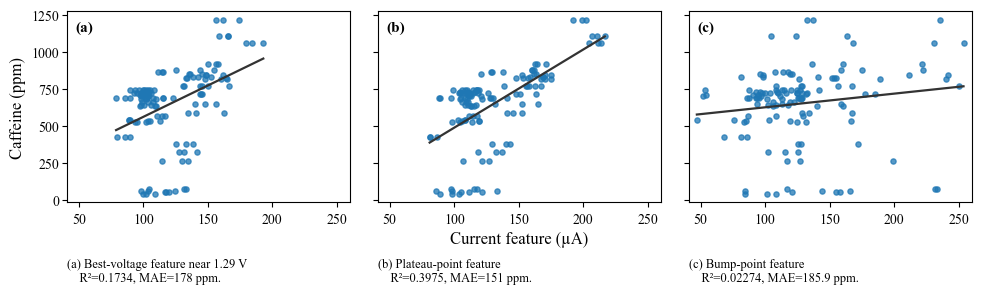

Saved: /Users/ryankoes/PycharmProjects/CoffeeAnalysis/Plots/Caffeine_three_regressions.pdf
Voltage scan: best V=1.29 V (scan range 0.8–1.8 V, N=101), best R²=0.1734
Samples: bestV=132, plateau=132, bump=132


In [36]:
# Plot + save caffeine regressions (stacked 3-panel figure in ONE PDF page)
# Uses `caff_raw_results` computed in the previous cell.
#
# Panels are lettered (a/b/c). The descriptive labels + stats are moved into a caption panel.

import matplotlib.pyplot as plt

if "caff_raw_results" not in globals():
    raise RuntimeError("Missing `caff_raw_results`. Run the previous cell (regression) first.")

res = caff_raw_results
scan = res["scan"]
fits = res["fits"]
paths = res["paths"]
base_figsize = res["figsize"]

show_figures = True

# Make the stacked figure a bit narrower (thinner) to match the single-column style above.
# For horizontal inline, we use a wider aspect ratio.
WIDTH_SCALE = 0.85


def _draw_precomputed(ax, fit: dict) -> None:
    x = fit["x"]
    y = fit["y"]
    ax.scatter(x, y, s=14, alpha=0.75, zorder=2)
    ax.plot(fit["x_line"], fit["y_line"], color="0.2", linewidth=1.6, zorder=3)


def _panel_letter(ax, letter: str) -> None:
    ax.text(
        0.03,
        0.95,
        f"({letter})",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontweight="bold",
    )


def _caption_lines(letter: str, label: str, fit: dict | None) -> list[str]:
    title = f"({letter}) {label}"
    if fit is None:
        return [title, "    no usable samples."]
    r2 = float(fit["r2"])
    mae = float(fit["mae"])
    return [title, f"    R²={r2:.4g}, MAE={mae:.4g} ppm."]


# Determine shared axis limits across available fits
available = [fits["best"]]
if fits.get("plateau") is not None:
    available.append(fits["plateau"])
if fits.get("bump") is not None:
    available.append(fits["bump"])

x_min = float(min(float(f["x"].min()) for f in available))
x_max = float(max(float(f["x"].max()) for f in available))
y_min = float(min(float(f["y"].min()) for f in available))
y_max = float(max(float(f["y"].max()) for f in available))

# Slight padding
x_pad = 0.03 * (x_max - x_min) if x_max > x_min else 1.0
y_pad = 0.05 * (y_max - y_min) if y_max > y_min else 1.0

# Use GridSpec for horizontal layout: 1 row of plots, 1 row for text
# 3 columns.
w0, h = float(base_figsize[0]), float(base_figsize[1])
# Wider figure for 3 panels side-by-side
fig = plt.figure(figsize=(w0 * 3.0, h * 1.3))
# 2 rows (plots, captions), 3 columns
# Increase hspace to avoid overlapping x-axis labels with captions
gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 0.25], hspace=0.35, wspace=0.1)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
ax2 = fig.add_subplot(gs[0, 2], sharey=ax0)

# Caption axes aligned with plots
ax_cap0 = fig.add_subplot(gs[1, 0])
ax_cap1 = fig.add_subplot(gs[1, 1])
ax_cap2 = fig.add_subplot(gs[1, 2])

for ax in (ax_cap0, ax_cap1, ax_cap2):
    ax.axis("off")

# Panel a: best-voltage regression
_draw_precomputed(ax0, fits["best"])
_panel_letter(ax0, "a")

# Panel b: plateau-point regression
if fits.get("plateau") is not None:
    _draw_precomputed(ax1, fits["plateau"])
else:
    ax1.axis("off")
_panel_letter(ax1, "b")

# Panel c: bump-point regression
if fits.get("bump") is not None:
    _draw_precomputed(ax2, fits["bump"])
else:
    ax2.axis("off")
_panel_letter(ax2, "c")

# Set limits and common styling
for ax in (ax0, ax1, ax2):
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.tick_params(axis="y", pad=2)

# Shared Y axis: ticks only on the left-most
plt.setp(ax1.get_yticklabels(), visible=False)
plt.setp(ax2.get_yticklabels(), visible=False)

# X axis: labels on all (since side-by-side)
# Y label on left-most
ax0.set_ylabel("Caffeine (ppm)")
# Shared X label? Or individual? Let's put it on the middle one.
ax1.set_xlabel("Current feature (µA)")

# Caption generation
label_a = f"Best-voltage feature near {scan['best_v']:.3g} V"
label_b = "Plateau-point feature"
label_c = "Bump-point feature"

def _render_caption(ax, letter, label, fit_data):
    lines = _caption_lines(letter, label, fit_data)
    text = "\n".join(lines)
    # Lower the starting position of the text in the caption box to give more breathing room
    ax.text(
        0.0,
        0.7, 
        text,
        ha="left",
        va="top",
        fontsize=9,
        transform=ax.transAxes,
    )

_render_caption(ax_cap0, "a", label_a, fits.get("best"))
_render_caption(ax_cap1, "b", label_b, fits.get("plateau"))
_render_caption(ax_cap2, "c", label_c, fits.get("bump"))

# Margins: standard
fig.subplots_adjust(left=0.08, right=0.98, top=0.95, bottom=0.05)

# Save
fig.savefig(paths["combined"], format="pdf")

if show_figures:
    plt.show()
plt.close(fig)

print(f"Saved: {paths['combined']}")
print(
    f"Voltage scan: best V={scan['best_v']:.6g} V (scan range {scan['vmin']}–{scan['vmax']} V, N={scan['n']}), best R²={scan['best_r2']:.4g}"
)
print(
    f"Samples: bestV={res['counts']['best']}, plateau={res['counts']['plateau']}, bump={res['counts']['bump']}"
)


best: R²=0.1734, MAE=178 ppm (n=132)
Saved: /Users/ryankoes/PycharmProjects/CoffeeAnalysis/Plots/Caffeine_regression_best_voltage.pdf


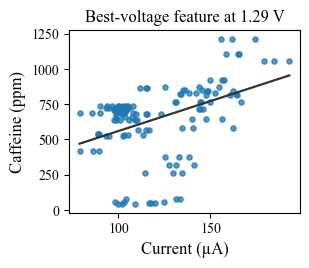

plateau: R²=0.3975, MAE=151 ppm (n=132)
Saved: /Users/ryankoes/PycharmProjects/CoffeeAnalysis/Plots/Caffeine_regression_plateau_point.pdf


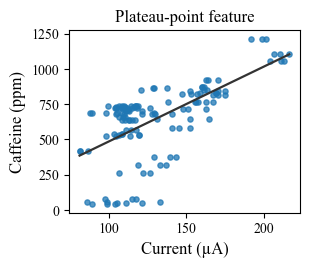

bump: R²=0.02274, MAE=185.9 ppm (n=132)
Saved: /Users/ryankoes/PycharmProjects/CoffeeAnalysis/Plots/Caffeine_regression_bump_point.pdf


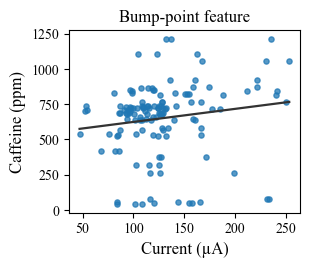

In [47]:
# Other plotting here
# Raw caffeine model: generate THREE separate plots (best / plateau / bump)
# Uses `caff_raw_results` from the regression compute cell.

import matplotlib.pyplot as plt

if "caff_raw_results" not in globals():
    raise RuntimeError("Missing `caff_raw_results`. Run the raw regression compute cell first.")

res = caff_raw_results
scan = res["scan"]
fits = res["fits"]
paths = res["paths"]
base_figsize = res["figsize"]

show_figures = True
WIDTH_SCALE = 0.85


def _plot_one(key: str, label: str) -> None:
    fit = fits.get(key)
    if fit is None:
        print(f"Skipping {key}: no usable samples")
        return

    w0, h0 = float(base_figsize[0]), float(base_figsize[1])
    fig, ax = plt.subplots(figsize=(w0 * WIDTH_SCALE, h0))

    ax.scatter(fit["x"], fit["y"], s=14, alpha=0.75, zorder=2)
    ax.plot(fit["x_line"], fit["y_line"], color="0.2", linewidth=1.6, zorder=3)

    # Title: label only (stats printed below)
    ax.set_title(label)

    ax.set_xlabel("Current (µA)")
    ax.set_ylabel("Caffeine (ppm)")

    fig.subplots_adjust(left=0.16, right=0.97, top=0.90, bottom=0.14)

    out = paths[key]
    fig.savefig(out, format="pdf")

    r2 = float(fit["r2"])
    mae = float(fit["mae"])
    n = int(getattr(fit["x"], "size", len(fit["x"])))
    print(f"{key}: R²={r2:.4g}, MAE={mae:.4g} ppm (n={n})")
    print(f"Saved: {out}")

    if show_figures:
        plt.show()
    plt.close(fig)


_plot_one("best", f"Best-voltage feature at {scan['best_v']:.3g} V")
_plot_one("plateau", "Plateau-point feature")
_plot_one("bump", "Bump-point feature")

In [42]:
# Same as the previous caffeine regression, but strength-normalize each voltammogram
# before feature extraction/regression.
#
# Strength normalization here matches the earlier notebook plot labeled “Normalized (0.8 V response)”,
# using nearest-point at 0.8 V:
#   I_norm(V) = I(V) - I(0.8 V)
#
# This cell ONLY computes the regression inputs + fits and stores them in `caff_norm_results`.
# Plotting/saving is in the next cell so you can tweak aesthetics without rerunning regression.

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

_required = [
    "read_coffehub",
    "_resolve_volt_path",
    "_load_curve_oxidation_smoothed",
    "_feature_at_voltage",
    "_feature_plateau_lowest_slope",
    "_feature_bump_steepest_slope_descent",
    "PLOTS_DIR",
]
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "Missing helpers from the previous cell: "
        + ", ".join(_missing)
        + "\nRun the previous caffeine regression cell first."
    )

V_REF = 0.8  # reference voltage for strength normalization

def _strength_normalize_curve(
    potential_ox: np.ndarray,
    current_ox: np.ndarray,
    *,
    v_ref: float = V_REF,
) -> np.ndarray:
    i_ref = _feature_at_voltage(potential_ox, current_ox, v_ref)
    return current_ox - float(i_ref)


def _fit_lr_1d(x: np.ndarray, y: np.ndarray) -> dict:
    """Fit LinearRegression on 1D x; return model + precomputed line + metrics."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    model = LinearRegression()
    model.fit(x.reshape(-1, 1), y)
    y_pred = model.predict(x.reshape(-1, 1))
    r2 = float(r2_score(y, y_pred))
    mae = float(mean_absolute_error(y, y_pred))

    x_min, x_max = float(np.min(x)), float(np.max(x))
    x_line = np.linspace(x_min, x_max, 200)
    y_line = model.predict(x_line.reshape(-1, 1))

    return {
        "model": model,
        "x": x,
        "y": y,
        "y_pred": y_pred,
        "r2": r2,
        "mae": mae,
        "x_line": x_line,
        "y_line": y_line,
    }


# Build caffeine dataset (one sample per voltammetry curve) using strength-normalized currents
df = read_coffehub(use_cache=True)
required_cols = {"HPLC_Caff", "cv_data1", "cv_data2", "cv_data3"}
missing = sorted(c for c in required_cols if c not in df.columns)
if missing:
    raise KeyError(f"CoffeeHub data missing required columns: {missing}")

curves_norm: list[tuple[np.ndarray, np.ndarray, float, str]] = []
for _, row in df.iterrows():
    y_truth = row.get("HPLC_Caff")
    if y_truth is None:
        continue
    try:
        if not np.isfinite(float(y_truth)):
            continue
    except Exception:
        continue
    y_truth = float(y_truth)

    for col in ("cv_data1", "cv_data2", "cv_data3"):
        vf = row.get(col)
        if vf is None:
            continue
        path = _resolve_volt_path(str(vf))
        if path is None:
            continue
        loaded = _load_curve_oxidation_smoothed(path)
        if loaded is None:
            continue
        potential_ox, current_ox = loaded
        if potential_ox.size < 3:
            continue
        current_norm = _strength_normalize_curve(potential_ox, current_ox, v_ref=V_REF)
        curves_norm.append((potential_ox, current_norm, y_truth, str(vf)))

if not curves_norm:
    raise ValueError("No usable voltammetry curves found for strength-normalized caffeine regression")

# 1) Scan voltages to find best R²
scan_vmin, scan_vmax, scan_n = 0.8, 1.8, 101
scan_voltages = np.linspace(scan_vmin, scan_vmax, scan_n)
best_v = None
best_r2 = -np.inf

for v in scan_voltages:
    xs = []
    ys = []
    for potential_ox, current_norm, y_truth, _ in curves_norm:
        xs.append(_feature_at_voltage(potential_ox, current_norm, float(v)))
        ys.append(y_truth)
    x_arr = np.asarray(xs, dtype=float)
    y_arr = np.asarray(ys, dtype=float)
    if x_arr.size < 2:
        continue
    model = LinearRegression()
    model.fit(x_arr.reshape(-1, 1), y_arr)
    y_pred = model.predict(x_arr.reshape(-1, 1))
    r2 = float(r2_score(y_arr, y_pred))
    if r2 > best_r2:
        best_r2 = r2
        best_v = float(v)

if best_v is None:
    raise ValueError("Voltage scan failed to find a best voltage (strength-normalized)")

# Gather features for the 3 regressions
x_best = []
y_best = []
x_plateau = []
y_plateau = []
x_bump = []
y_bump = []

for potential_ox, current_norm, y_truth, _ in curves_norm:
    x_best.append(_feature_at_voltage(potential_ox, current_norm, best_v))
    y_best.append(y_truth)

    feat_plateau = _feature_plateau_lowest_slope(potential_ox, current_norm, vmin=1.2, vmax=1.6)
    if feat_plateau is not None:
        x_plateau.append(feat_plateau)
        y_plateau.append(y_truth)

    feat_bump = _feature_bump_steepest_slope_descent(potential_ox, current_norm, vmin=1.1, vmax=1.5)
    if feat_bump is not None:
        x_bump.append(feat_bump)
        y_bump.append(y_truth)

x_best = np.asarray(x_best, dtype=float)
y_best = np.asarray(y_best, dtype=float)
x_plateau = np.asarray(x_plateau, dtype=float)
y_plateau = np.asarray(y_plateau, dtype=float)
x_bump = np.asarray(x_bump, dtype=float)
y_bump = np.asarray(y_bump, dtype=float)

# Output files (keep originals intact; write a separate normalized set)
out_path = PLOTS_DIR / "Caffeine_three_regressions_strength_normalized.pdf"
out_best = PLOTS_DIR / "Caffeine_regression_best_voltage_strength_normalized.pdf"
out_plateau = PLOTS_DIR / "Caffeine_regression_plateau_point_strength_normalized.pdf"
out_bump = PLOTS_DIR / "Caffeine_regression_bump_point_strength_normalized.pdf"

caff_norm_results = {
    "scan": {
        "vmin": float(scan_vmin),
        "vmax": float(scan_vmax),
        "n": int(scan_n),
        "best_v": float(best_v),
        "best_r2": float(best_r2),
    },
    "fits": {
        "best": _fit_lr_1d(x_best, y_best),
        "plateau": _fit_lr_1d(x_plateau, y_plateau) if x_plateau.size >= 2 else None,
        "bump": _fit_lr_1d(x_bump, y_bump) if x_bump.size >= 2 else None,
    },
    "paths": {
        "combined": out_path,
        "best": out_best,
        "plateau": out_plateau,
        "bump": out_bump,
    },
    "figsize": globals().get("FIGSIZE_SINGLE_COLUMN", (7.0, 5.0)),
    "counts": {
        "best": int(x_best.size),
        "plateau": int(x_plateau.size),
        "bump": int(x_bump.size),
    },
    "strength_norm": {
        "v_ref": float(V_REF),
        "xlabel_suffix": f" (I − I({V_REF:.3g} V))",
    },
}


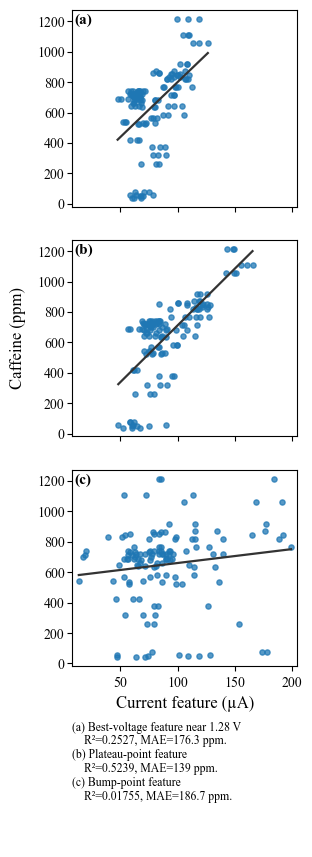

Saved: /Users/ryankoes/PycharmProjects/CoffeeAnalysis/Plots/Caffeine_three_regressions_strength_normalized.pdf
Voltage scan: best V=1.28 V (scan range 0.8–1.8 V, N=101), best R²=0.2527
Samples: bestV=132, plateau=132, bump=132


In [43]:
# Plot + save caffeine regressions (strength-normalized) (stacked 3-panel figure in ONE PDF page)
# Uses `caff_norm_results` computed in the previous cell.

import matplotlib.pyplot as plt

if "caff_norm_results" not in globals():
    raise RuntimeError("Missing `caff_norm_results`. Run the previous cell (regression) first.")

res = caff_norm_results
scan = res["scan"]
fits = res["fits"]
paths = res["paths"]
base_figsize = res["figsize"]

show_figures = True

# Make the stacked figure a bit narrower (thinner) to match the single-column style above.
WIDTH_SCALE = 0.85


def _draw_precomputed(ax, fit: dict) -> None:
    x = fit["x"]
    y = fit["y"]
    ax.scatter(x, y, s=14, alpha=0.75, zorder=2)
    ax.plot(fit["x_line"], fit["y_line"], color="0.2", linewidth=1.6, zorder=3)


def _panel_letter(ax, letter: str) -> None:
    ax.text(
        0.01,
        0.98,
        f"({letter})",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontweight="bold",
    )


def _caption_lines(letter: str, label: str, fit: dict | None) -> list[str]:
    title = f"({letter}) {label}"
    if fit is None:
        return [title, "    no usable samples."]
    r2 = float(fit["r2"])
    mae = float(fit["mae"])
    return [title, f"    R²={r2:.4g}, MAE={mae:.4g} ppm."]


# Determine shared axis limits across available fits
available = [fits["best"]]
if fits.get("plateau") is not None:
    available.append(fits["plateau"])
if fits.get("bump") is not None:
    available.append(fits["bump"])

x_min = float(min(float(f["x"].min()) for f in available))
x_max = float(max(float(f["x"].max()) for f in available))
y_min = float(min(float(f["y"].min()) for f in available))
y_max = float(max(float(f["y"].max()) for f in available))

# Slight padding
x_pad = 0.03 * (x_max - x_min) if x_max > x_min else 1.0
y_pad = 0.05 * (y_max - y_min) if y_max > y_min else 1.0

# Use GridSpec with a dedicated caption row so the plots keep full width.
# Keep per-panel height; add extra height for the caption.
w0, h = float(base_figsize[0]), float(base_figsize[1])
w = w0 * WIDTH_SCALE
fig = plt.figure(figsize=(w, h * 3.0 + h * 0.75))
# Smaller hspace brings panels closer vertically
gs = fig.add_gridspec(4, 1, height_ratios=[1.0, 1.0, 1.0, 0.75], hspace=0.18)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0], sharex=ax0, sharey=ax0)
ax2 = fig.add_subplot(gs[2, 0], sharex=ax0, sharey=ax0)
ax_cap = fig.add_subplot(gs[3, 0])
ax_cap.axis("off")

# Panel a: best-voltage regression
_draw_precomputed(ax0, fits["best"])
_panel_letter(ax0, "a")

# Panel b: plateau-point regression
if fits.get("plateau") is not None:
    _draw_precomputed(ax1, fits["plateau"])
else:
    ax1.axis("off")
_panel_letter(ax1, "b")

# Panel c: bump-point regression
if fits.get("bump") is not None:
    _draw_precomputed(ax2, fits["bump"])
else:
    ax2.axis("off")
_panel_letter(ax2, "c")

for ax in (ax0, ax1, ax2):
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.tick_params(axis="y", pad=2)

# Shared x-axis: show ticks/labels only on the bottom panel
ax0.tick_params(axis="x", labelbottom=False)
ax1.tick_params(axis="x", labelbottom=False)

# Labels: put the y label on the middle subplot to avoid figure-level overlap
ax1.set_ylabel("Caffeine (ppm)", labelpad=8)
ax2.set_xlabel("Current feature (µA)")

# Caption with extracted labels + stats (two lines per panel)
label_a = f"Best-voltage feature near {scan['best_v']:.3g} V"
label_b = "Plateau-point feature"
label_c = "Bump-point feature"

caption_lines: list[str] = []
caption_lines.extend(_caption_lines("a", label_a, fits.get("best")))
caption_lines.extend(_caption_lines("b", label_b, fits.get("plateau")))
caption_lines.extend(_caption_lines("c", label_c, fits.get("bump")))
caption = "\n".join(caption_lines)

# Move caption down within its row to keep it clear of the x-axis label.
CAPTION_Y = 0.85
ax_cap.text(
    0.0,
    CAPTION_Y,
    caption,
    ha="left",
    va="top",
    fontsize=8.5,
    transform=ax_cap.transAxes,
)

# Margins: slightly larger left margin to protect y tick labels on a thinner page
fig.subplots_adjust(left=0.18, right=0.97, top=0.98, bottom=0.05)

# Save ONE page PDF (stacked). Avoid bbox_inches='tight' so the figure keeps its intended width.
fig.savefig(paths["combined"], format="pdf")

if show_figures:
    plt.show()
plt.close(fig)

print(f"Saved: {paths['combined']}")
print(
    f"Voltage scan: best V={scan['best_v']:.6g} V (scan range {scan['vmin']}–{scan['vmax']} V, N={scan['n']}), best R²={scan['best_r2']:.4g}"
)
print(
    f"Samples: bestV={res['counts']['best']}, plateau={res['counts']['plateau']}, bump={res['counts']['bump']}"
)


best: R²=0.2527, MAE=176.3 ppm (n=132)
Saved: /Users/ryankoes/PycharmProjects/CoffeeAnalysis/Plots/Caffeine_regression_best_voltage_strength_normalized.pdf


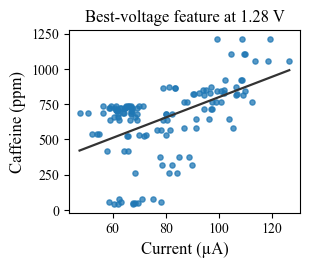

plateau: R²=0.5239, MAE=139 ppm (n=132)
Saved: /Users/ryankoes/PycharmProjects/CoffeeAnalysis/Plots/Caffeine_regression_plateau_point_strength_normalized.pdf


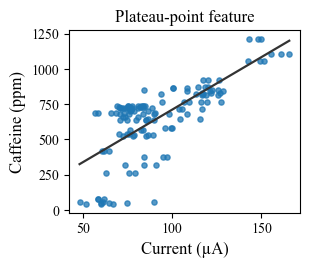

bump: R²=0.01755, MAE=186.7 ppm (n=132)
Saved: /Users/ryankoes/PycharmProjects/CoffeeAnalysis/Plots/Caffeine_regression_bump_point_strength_normalized.pdf


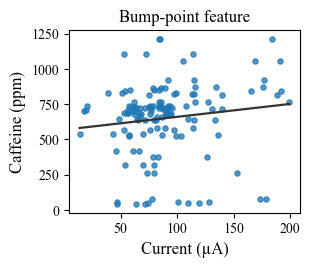

In [48]:
# Other plotting here
# Strength-normalized caffeine model: generate THREE separate plots (best / plateau / bump)
# Uses `caff_norm_results` from the regression compute cell.

import matplotlib.pyplot as plt

if "caff_norm_results" not in globals():
    raise RuntimeError("Missing `caff_norm_results`. Run the strength-normalized regression compute cell first.")

res = caff_norm_results
scan = res["scan"]
fits = res["fits"]
paths = res["paths"]
base_figsize = res["figsize"]

xlabel_suffix = res.get("strength_norm", {}).get("xlabel_suffix", "")

show_figures = True
WIDTH_SCALE = 0.85


def _plot_one(key: str, label: str) -> None:
    fit = fits.get(key)
    if fit is None:
        print(f"Skipping {key}: no usable samples")
        return

    w0, h0 = float(base_figsize[0]), float(base_figsize[1])
    fig, ax = plt.subplots(figsize=(w0 * WIDTH_SCALE, h0))

    ax.scatter(fit["x"], fit["y"], s=14, alpha=0.75, zorder=2)
    ax.plot(fit["x_line"], fit["y_line"], color="0.2", linewidth=1.6, zorder=3)

    # Title: label only (stats printed below)
    ax.set_title(label)

    ax.set_xlabel(f"Current (µA)")
    ax.set_ylabel("Caffeine (ppm)")

    fig.subplots_adjust(left=0.16, right=0.97, top=0.90, bottom=0.14)

    out = paths[key]
    fig.savefig(out, format="pdf")

    r2 = float(fit["r2"])
    mae = float(fit["mae"])
    n = int(getattr(fit["x"], "size", len(fit["x"])))
    print(f"{key}: R²={r2:.4g}, MAE={mae:.4g} ppm (n={n})")
    print(f"Saved: {out}")

    if show_figures:
        plt.show()
    plt.close(fig)


_plot_one("best", f"Best-voltage feature at {scan['best_v']:.3g} V")
_plot_one("plateau", "Plateau-point feature")
_plot_one("bump", "Bump-point feature")
